# Chapter 10: Spaces of Curvature Bounded Below

**Source span.** *A Course in Metric Geometry*, Chapter 10, printed pages 351-404, PDF pages 366-419. The PDF span was used for chapter structure, terminology, theorem ordering, and coverage only; the explanations, examples, computations, and diagrams here are original.

**Chapter question.** What does a lower curvature bound mean when there is no smooth curvature tensor, and why does it still force global comparison, compactness, volume control, and a Euclidean-looking regular set?

The chapter is the mirror partner to CAT geometry, but the mirror is not a sign change. In CAT spaces an upper curvature bound makes triangles no thicker than a model. In CBB spaces a lower curvature bound controls how fast geodesics can spread, so comparison angles, diameters, volume growth, and tangent cones become the main instruments. The central result is Toponogov's theorem: a local Alexandrov lower bound propagates to global triangle comparison in a complete length space.


## Translation Guide

| Book idea | Computational representation used here | Inspection target |
| --- | --- | --- |
| Quadruple condition | A fan of comparison angles at one vertex | The sum of three comparison angles is at most `2*pi`; Euclidean equality is the calibration case. |
| Toponogov hinge comparison | Model-space law of cosines for `k=-1,0,1` | For fixed legs and included angle, the model opposite side decreases as the lower curvature bound increases. |
| Cones, quotients, convex surfaces | Sector, fold, and convex cap diagrams | Singularities are legal when links/directions keep the right lower-curvature behavior. |
| Diameter and splitting | Positive-curvature diameter bound and a product strip | Positive lower curvature limits diameter; a line in nonnegative curvature forces an `R x Y` product. |
| Dimension and volume | Bishop/Gromov-Bishop comparison curves and collapsing rectangles | Volume growth is bounded by the model; GH limits may drop dimension. |
| Local structure | Strainers, spaces of directions, and tangent cones | Regular points have spherical directions and Euclidean tangent cones; singular points fail this link test. |


In [1]:
from __future__ import annotations

from pathlib import Path
import json, math

import matplotlib
matplotlib.use("Agg")
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import HTML, Image, display

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break

ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "chapter-10"
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "html"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
for folder in [FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

STYLE = {"ink": "#263238", "blue": "#2d6cdf", "green": "#238b45", "red": "#c2410c", "gold": "#b7791f", "violet": "#6d4c9f", "gray": "#6b7280"}

def rel(path: Path) -> str:
    return str(path.relative_to(BOOK_ROOT)).replace("\\", "/")

def display_artifact(path: Path, width: int | None = None):
    path = Path(path)
    if path.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        display(Image(filename=str(path), width=width))
    elif path.suffix.lower() == ".html":
        display(HTML(f'<a href="../{rel(path)}" target="_blank">Open {path.name}</a>'))
    else:
        display(HTML(f"<code>{rel(path)}</code>"))

def clamp(x, lo=-1.0, hi=1.0):
    return max(lo, min(hi, x))

def sn_k(r: float | np.ndarray, k: float):
    r = np.asarray(r)
    if abs(k) < 1e-12:
        return r
    root = math.sqrt(abs(k))
    return np.sin(root * r) / root if k > 0 else np.sinh(root * r) / root

def comparison_side(a: float, b: float, theta: float, k: float) -> float:
    if abs(k) < 1e-12:
        return math.sqrt(max(0.0, a*a + b*b - 2*a*b*math.cos(theta)))
    root = math.sqrt(abs(k))
    if k > 0:
        value = math.cos(root*a)*math.cos(root*b) + math.sin(root*a)*math.sin(root*b)*math.cos(theta)
        return math.acos(clamp(value)) / root
    value = math.cosh(root*a)*math.cosh(root*b) - math.sinh(root*a)*math.sinh(root*b)*math.cos(theta)
    return math.acosh(max(1.0, value)) / root

def euclidean_angle(u, v) -> float:
    u = np.asarray(u, dtype=float); v = np.asarray(v, dtype=float)
    return math.acos(clamp(float(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v)))))

def ball_volume_model(n: int, k: float, r: float, samples: int = 1400) -> float:
    omega = 2 * math.pi ** (n / 2) / math.gamma(n / 2)
    ts = np.linspace(0.0, r, samples)
    return float(omega * np.trapz(sn_k(ts, k) ** (n - 1), ts))

print(f"BOOK_ROOT = {BOOK_ROOT}")
print(f"Artifacts: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


BOOK_ROOT = D:\Geometry\A-Course-in-Metric-Geometry
Artifacts: artifacts\chapter-10


## Library Routing

This is mostly synthetic metric geometry, so the notebook uses small, inspectable tools: `matplotlib` for comparison diagrams and tangent-cone sketches, `networkx` for theorem dependencies, `numpy` and `pandas` for model-space checks and Bishop-volume tables, and a standalone HTML/JavaScript hinge lab so the main interaction survives outside a live kernel.


## CBB(k) Through a Quadruple Fan and a Hinge

Section 10.1 adds the quadruple condition: for four nearby points `a,b,c,d`, the three model comparison angles at the distinguished point `a` satisfy a `<= 2*pi` fan inequality. The left panel calibrates this in the Euclidean plane, where the angles exactly fill a full turn.

Toponogov's theorem globalizes the lower bound. A useful hinge reading is: for fixed legs and included angle, higher model curvature gives a smaller opposite side. A CBB(k) space is not allowed to spread faster than the `k`-model hinge.


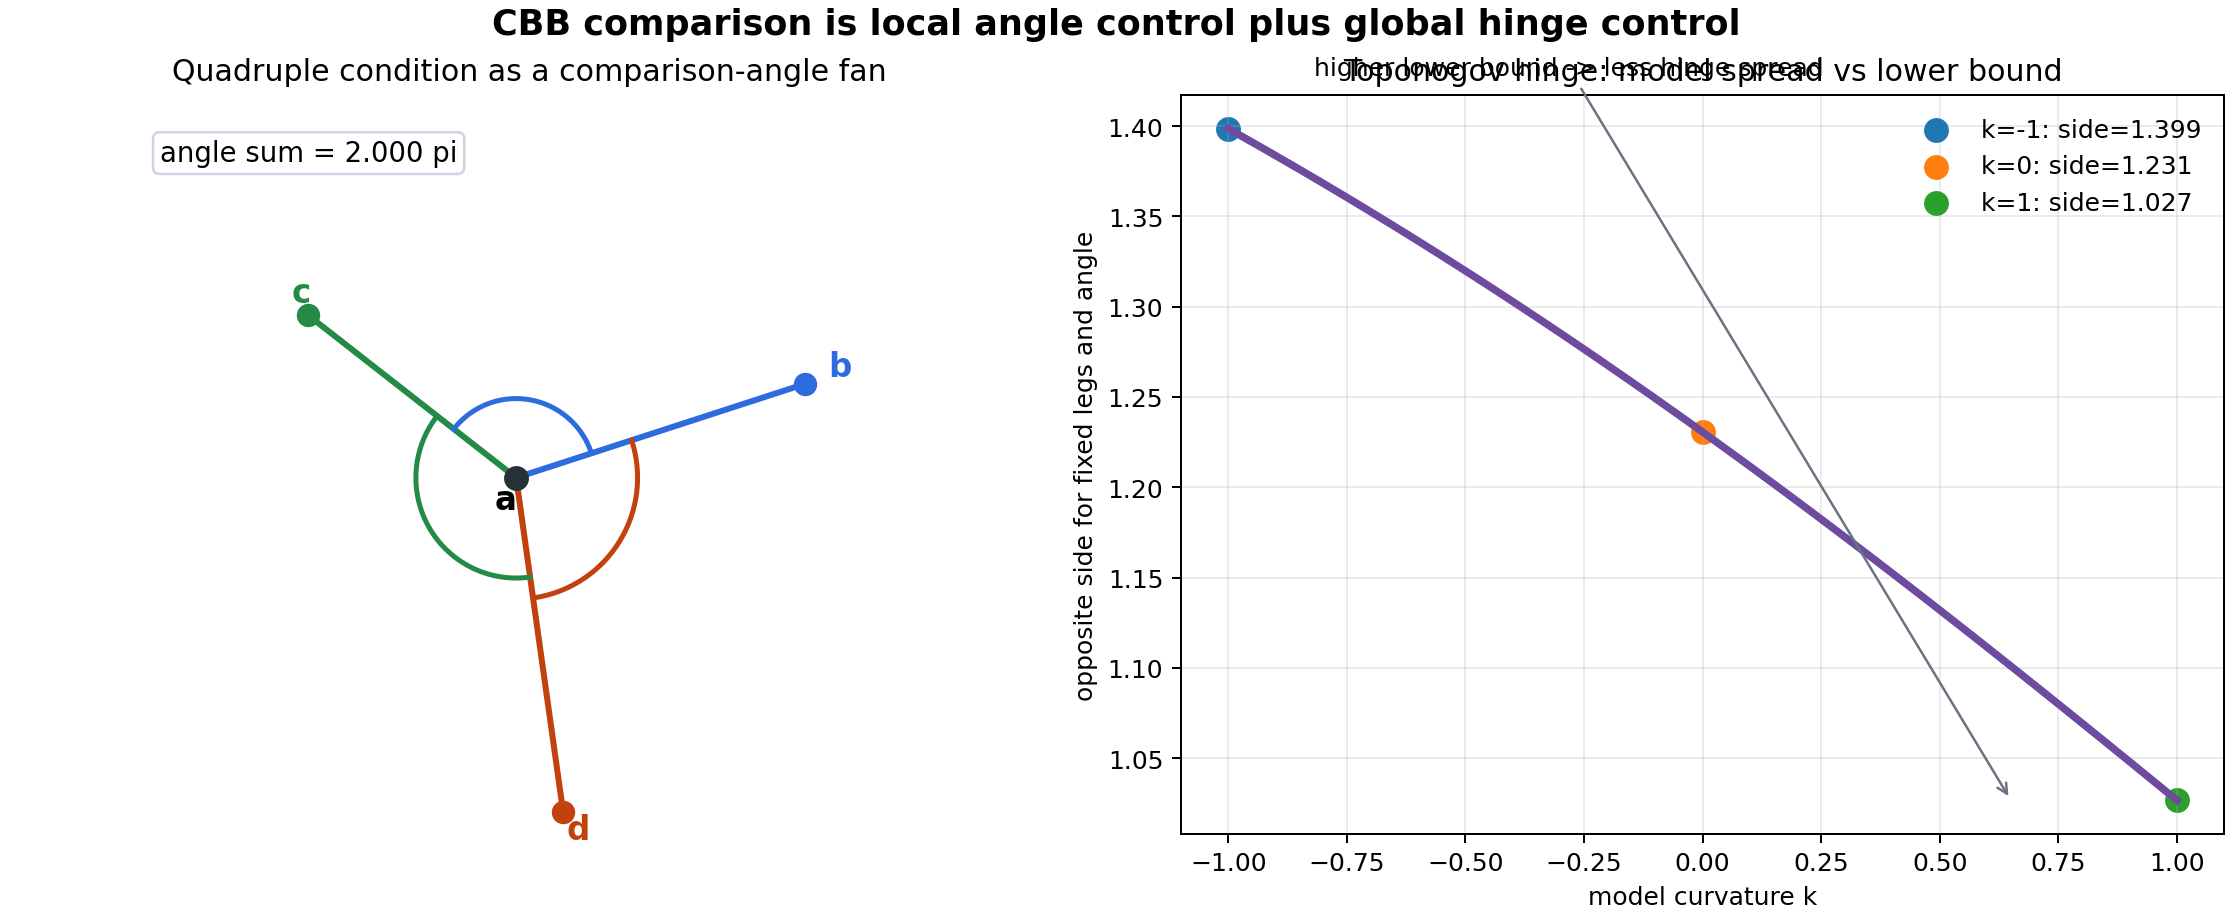

In [2]:
quad_path = FIG_DIR / "quadruple-toponogov-comparison.png"
hinge_json = CHECK_DIR / "toponogov-hinge-invariants.json"

angles = np.deg2rad([18, 142, 278])
radii = np.array([1.15, 1.0, 1.28])
points = [r * np.array([math.cos(t), math.sin(t)]) for r, t in zip(radii, angles)]
fan_angles = [euclidean_angle(points[0], points[1]), euclidean_angle(points[1], points[2]), 2 * math.pi - (angles[2] - angles[0])]
fan_sum = sum(fan_angles)

leg_a, leg_b, theta = 1.25, 1.05, math.radians(64)
k_values = np.linspace(-1.0, 1.0, 81)
side_values = np.array([comparison_side(leg_a, leg_b, theta, float(k)) for k in k_values])
model_samples = {-1: comparison_side(leg_a, leg_b, theta, -1.0), 0: comparison_side(leg_a, leg_b, theta, 0.0), 1: comparison_side(leg_a, leg_b, theta, 1.0)}

fig, axs = plt.subplots(1, 2, figsize=(12.4, 5.1), constrained_layout=True)
ax = axs[0]
for p, label, color in zip(points, ["b", "c", "d"], [STYLE["blue"], STYLE["green"], STYLE["red"]]):
    ax.plot([0, p[0]], [0, p[1]], color=color, lw=2.4)
    ax.scatter([p[0]], [p[1]], s=70, color=color, zorder=5)
    ax.text(p[0] * 1.08, p[1] * 1.08, label, fontsize=13, weight="bold", color=color)
ax.scatter([0], [0], s=80, color=STYLE["ink"], zorder=6)
ax.text(-0.08, -0.12, "a", fontsize=13, weight="bold")
for rr, (lo, hi), color in zip([0.30, 0.38, 0.46], [(angles[0], angles[1]), (angles[1], angles[2]), (angles[2], angles[0] + 2 * math.pi)], [STYLE["blue"], STYLE["green"], STYLE["red"]]):
    ts = np.linspace(lo, hi, 80)
    ax.plot(rr * np.cos(ts), rr * np.sin(ts), color=color, lw=2)
ax.set_title("Quadruple condition as a comparison-angle fan")
ax.text(-1.35, 1.20, f"angle sum = {fan_sum / math.pi:.3f} pi", fontsize=11, bbox={"facecolor": "white", "edgecolor": "#cbd5e1", "boxstyle": "round,pad=0.25"})
ax.set_aspect("equal"); ax.set_xlim(-1.45, 1.55); ax.set_ylim(-1.35, 1.45); ax.axis("off")

ax = axs[1]
ax.plot(k_values, side_values, color=STYLE["violet"], lw=3)
for k, val in model_samples.items():
    ax.scatter([k], [val], s=80, label=f"k={k}: side={val:.3f}")
ax.set_title("Toponogov hinge: model spread vs lower bound")
ax.set_xlabel("model curvature k"); ax.set_ylabel("opposite side for fixed legs and angle")
ax.grid(alpha=0.25); ax.legend(frameon=False, loc="upper right")
ax.annotate("higher lower bound -> less hinge spread", xy=(0.65, model_samples[1]), xytext=(-0.82, model_samples[-1] + 0.03), arrowprops={"arrowstyle": "->", "color": STYLE["gray"]})
fig.suptitle("CBB comparison is local angle control plus global hinge control", fontsize=14, weight="bold")
fig.savefig(quad_path, dpi=180); plt.close(fig)

hinge_invariants = {
    "fixed_hinge": {"leg_a": leg_a, "leg_b": leg_b, "included_angle_degrees": math.degrees(theta)},
    "model_opposite_sides": {str(k): float(v) for k, v in model_samples.items()},
    "side_decreases_as_k_increases": bool(np.all(np.diff(side_values) <= 1e-9)),
    "quadruple_fan_sum_radians": fan_sum,
    "quadruple_fan_sum_minus_2pi_abs": abs(fan_sum - 2 * math.pi),
}
hinge_json.write_text(json.dumps(hinge_invariants, indent=2), encoding="utf-8")
display_artifact(quad_path, width=980)


## Constructions and Examples

Section 10.2 shows that CBB spaces are not only smooth manifolds. Products, cones, quotients by isometric group actions, and convex hypersurfaces produce spaces with lower curvature bounds. A lower bound tolerates singularities, but the singularity must have a controlled link: a cone point remembers its space of directions, and that link carries curvature information one dimension lower.


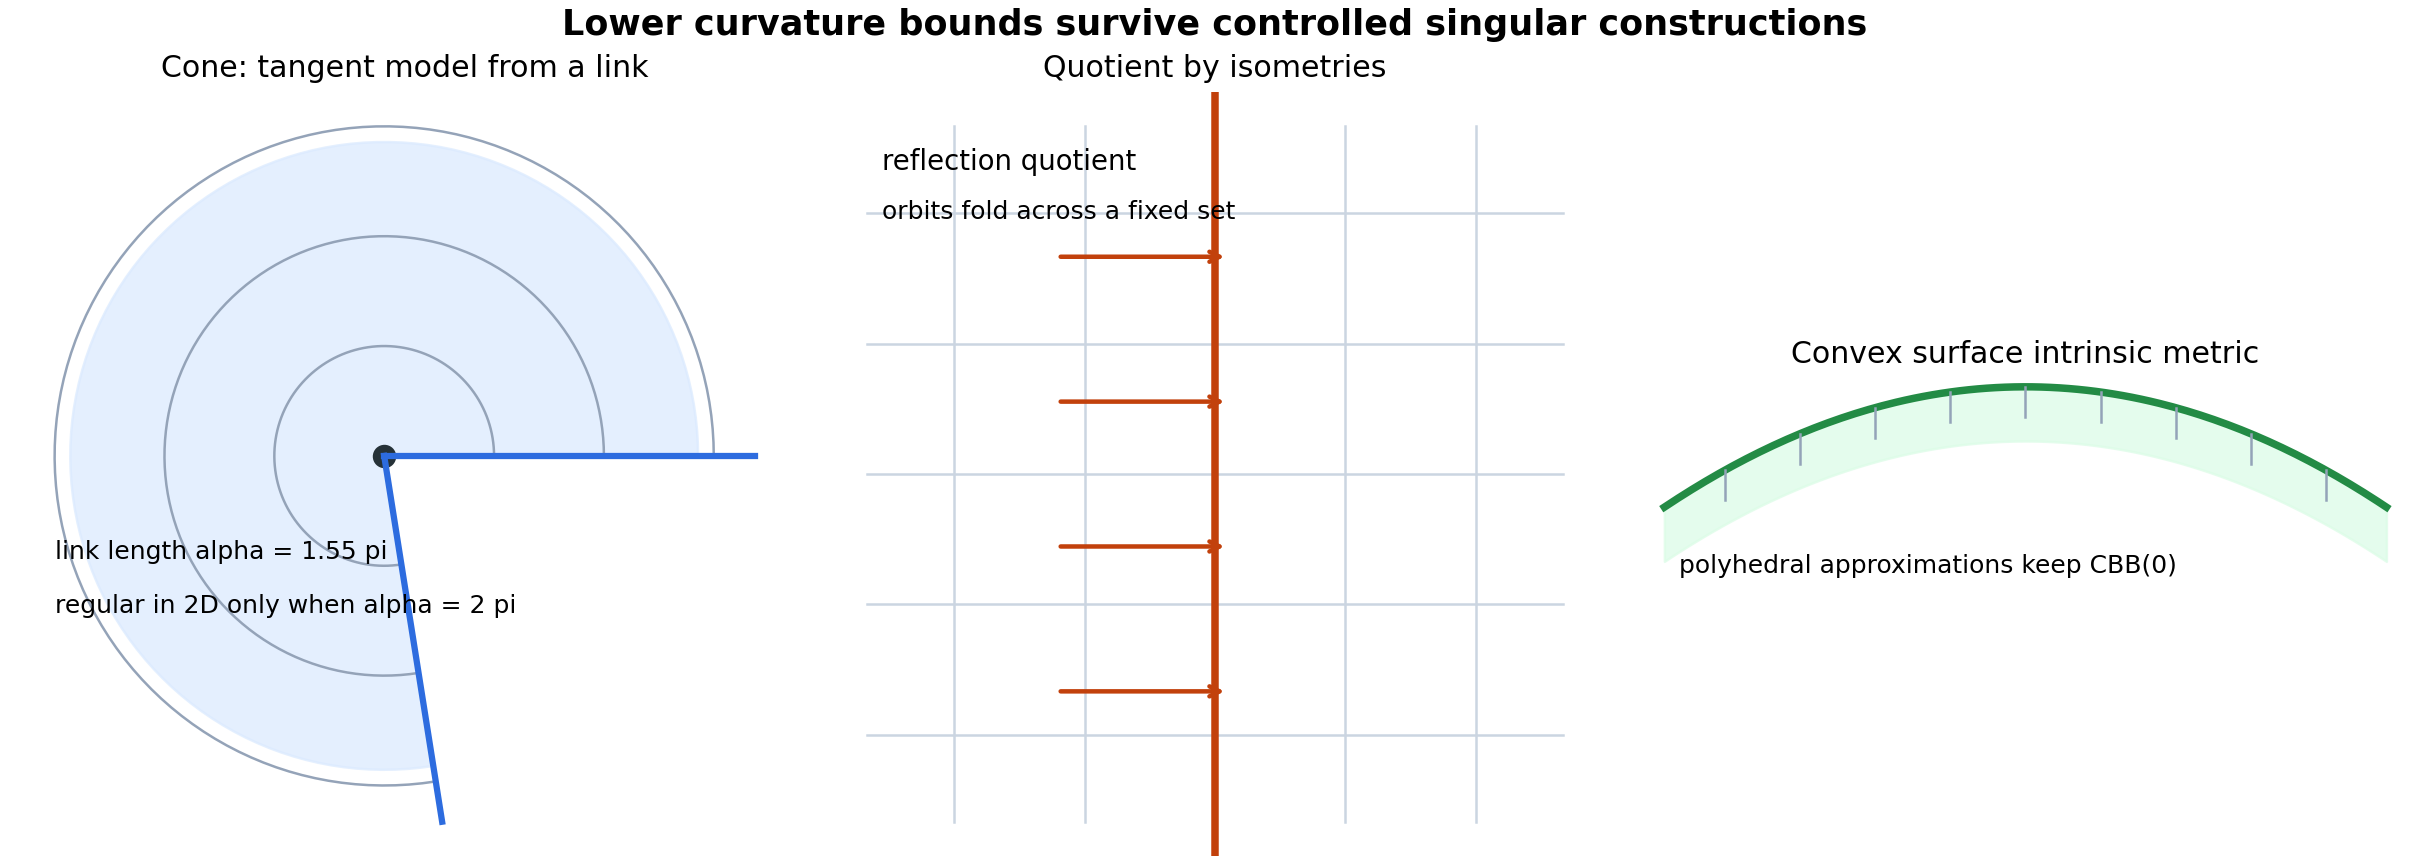

In [3]:
construction_path = FIG_DIR / "constructions-cones-quotients.png"
construction_json = CHECK_DIR / "construction-invariants.json"
alpha = 1.55 * math.pi
ts = np.linspace(0, alpha, 120)
fig, axs = plt.subplots(1, 3, figsize=(13.5, 4.8), constrained_layout=True)

ax = axs[0]
for rr in [0.35, 0.7, 1.05]:
    ax.plot(rr * np.cos(ts), rr * np.sin(ts), color="#94a3b8", lw=1)
for t in [0, alpha]:
    ax.plot([0, 1.18 * math.cos(t)], [0, 1.18 * math.sin(t)], color=STYLE["blue"], lw=2.5)
ax.fill(np.r_[0, np.cos(ts), 0], np.r_[0, np.sin(ts), 0], color="#dbeafe", alpha=0.75)
ax.scatter([0], [0], s=70, color=STYLE["ink"])
ax.set_title("Cone: tangent model from a link")
ax.text(-1.05, -0.33, f"link length alpha = {alpha / math.pi:.2f} pi", fontsize=10)
ax.text(-1.05, -0.50, "regular in 2D only when alpha = 2 pi", fontsize=10)
ax.set_aspect("equal"); ax.axis("off")

ax = axs[1]
x = np.linspace(-1.2, 1.2, 80)
for y in [-0.9, -0.45, 0, 0.45, 0.9]:
    ax.plot(x, np.full_like(x, y), color="#cbd5e1", lw=1)
for xx in [-0.9, -0.45, 0, 0.45, 0.9]:
    ax.plot(np.full_like(x, xx), x, color="#cbd5e1", lw=1)
ax.axvline(0, color=STYLE["red"], lw=3)
for y in [-0.75, -0.25, 0.25, 0.75]:
    ax.annotate("", xy=(0.05, y), xytext=(-0.55, y), arrowprops={"arrowstyle": "->", "color": STYLE["red"], "lw": 1.8})
ax.text(-1.15, 1.05, "reflection quotient", fontsize=11)
ax.text(-1.15, 0.88, "orbits fold across a fixed set", fontsize=10)
ax.set_title("Quotient by isometries"); ax.set_aspect("equal"); ax.axis("off")

ax = axs[2]
xx = np.linspace(-1.2, 1.2, 160)
yy = 0.40 * (1 - (xx / 1.2) ** 2)
ax.plot(xx, yy, color=STYLE["green"], lw=3)
for xp in np.linspace(-1.0, 1.0, 9):
    yp = 0.40 * (1 - (xp / 1.2) ** 2)
    ax.plot([xp, xp], [yp - 0.10, yp], color="#94a3b8", lw=1)
ax.fill_between(xx, yy, yy - 0.18, color="#dcfce7", alpha=0.75)
ax.set_title("Convex surface intrinsic metric")
ax.text(-1.15, -0.22, "polyhedral approximations keep CBB(0)", fontsize=10)
ax.set_aspect("equal"); ax.axis("off")

fig.suptitle("Lower curvature bounds survive controlled singular constructions", fontsize=14, weight="bold")
fig.savefig(construction_path, dpi=180); plt.close(fig)
construction_json.write_text(json.dumps({
    "cone_angle_alpha_over_pi": alpha / math.pi,
    "regular_cone_angle_over_pi": 2.0,
    "quotient_metric_principle": "distance between orbits is the infimum over representatives",
    "convex_surface_route": "approximate by convex polyhedra and pass the lower bound through GH limits",
}, indent=2), encoding="utf-8")
display_artifact(construction_path, width=980)


## Toponogov as the Chapter's Engine

The proof of Toponogov is technical, but the proof role is easy to track. The theorem upgrades a local lower bound into global triangle comparison. Once global comparison is available, the chapter can prove diameter bounds, splitting, volume comparison, closure under Gromov-Hausdorff limits, compactness with fixed dimension/diameter, and the tangent-cone machinery.


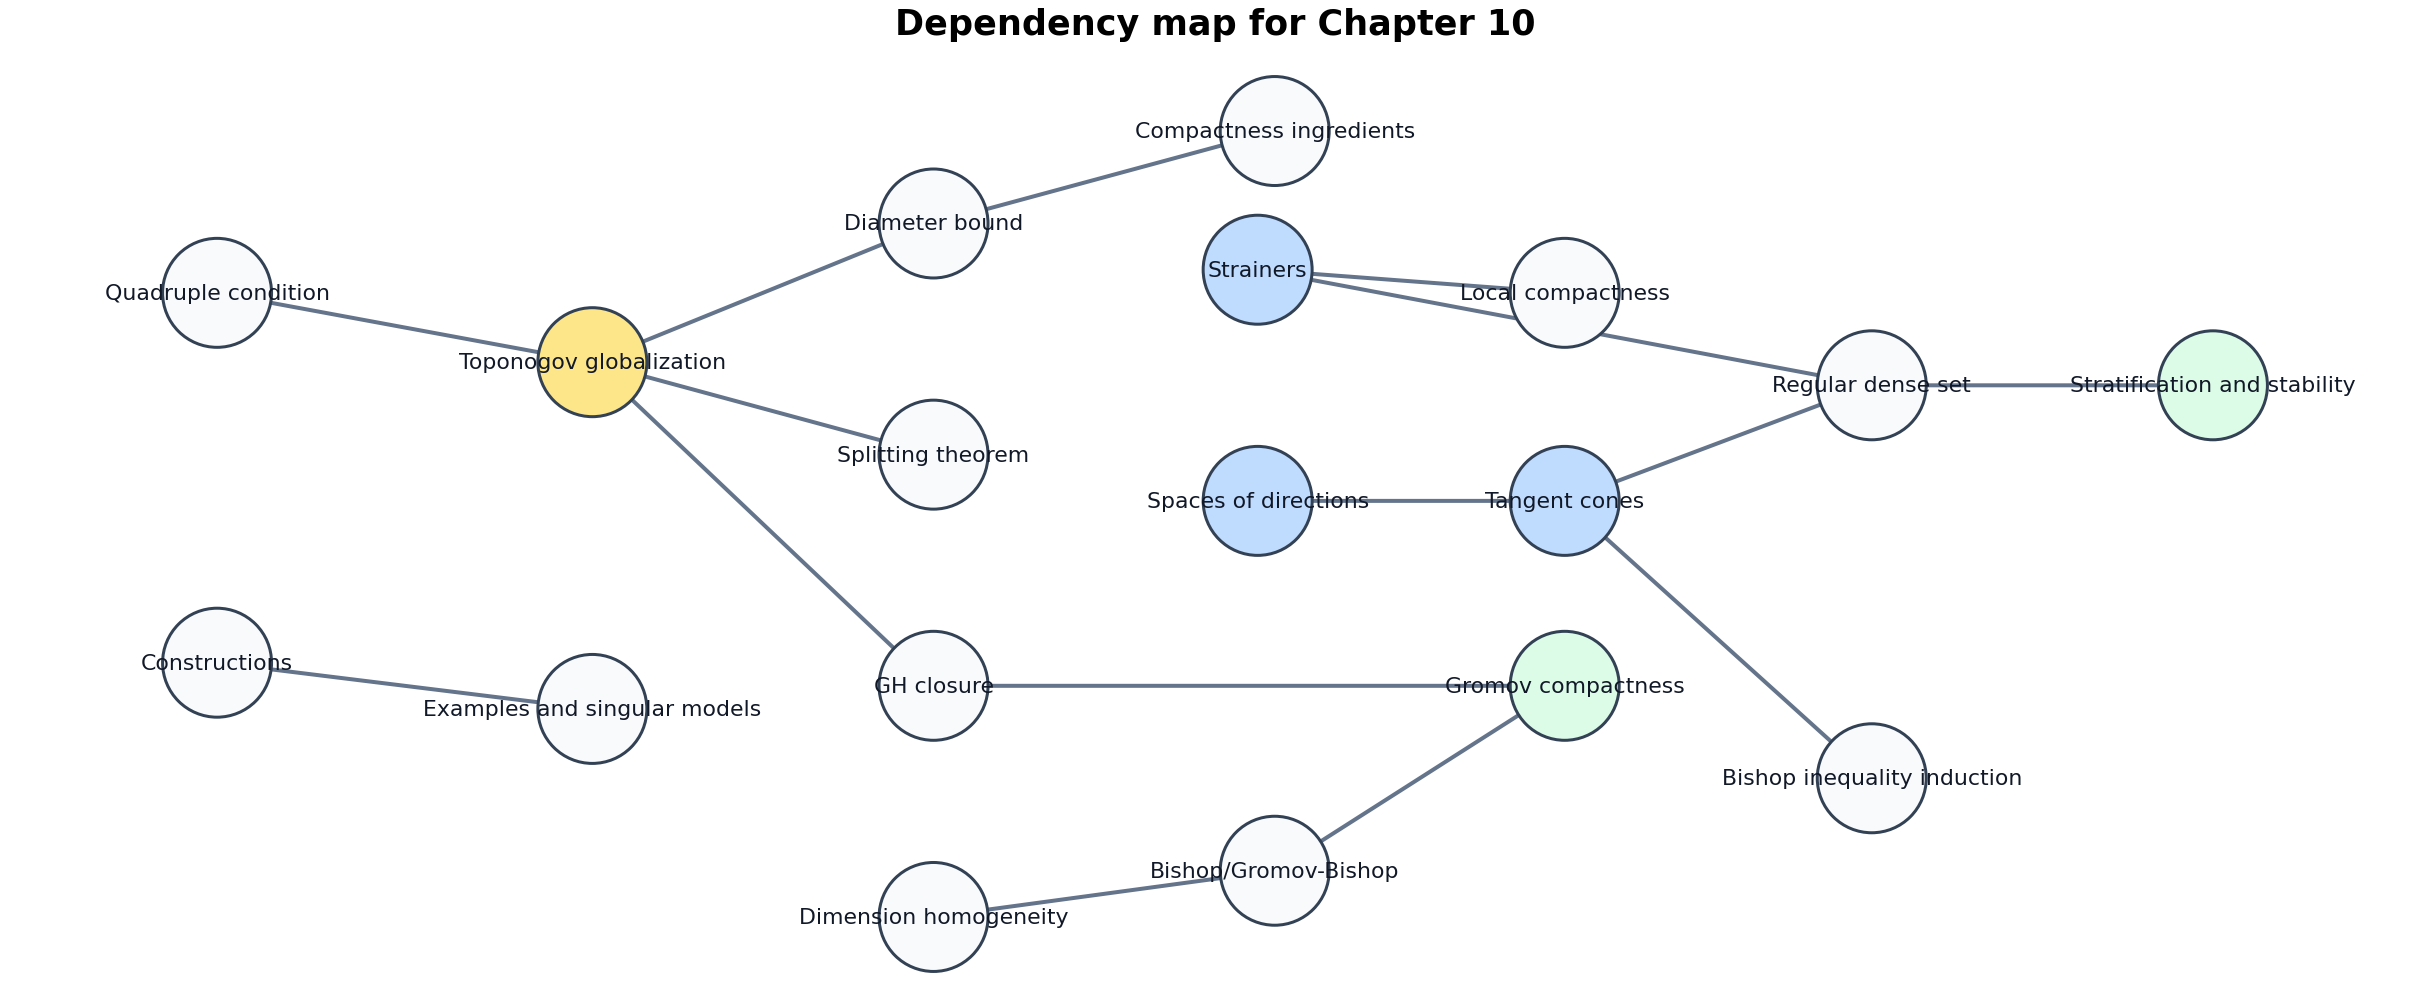

In [4]:
proof_path = FIG_DIR / "chapter-10-proof-dependency.png"
proof_json = CHECK_DIR / "proof-dependency-checks.json"
G = nx.DiGraph()
G.add_edges_from([
    ("Quadruple condition", "Toponogov globalization"), ("Constructions", "Examples and singular models"),
    ("Toponogov globalization", "Diameter bound"), ("Toponogov globalization", "Splitting theorem"), ("Toponogov globalization", "GH closure"),
    ("Diameter bound", "Compactness ingredients"), ("Dimension homogeneity", "Bishop/Gromov-Bishop"),
    ("Bishop/Gromov-Bishop", "Gromov compactness"), ("GH closure", "Gromov compactness"),
    ("Strainers", "Local compactness"), ("Strainers", "Regular dense set"),
    ("Spaces of directions", "Tangent cones"), ("Tangent cones", "Regular dense set"),
    ("Regular dense set", "Stratification and stability"), ("Tangent cones", "Bishop inequality induction"),
])
pos = {"Quadruple condition": (0, 2.7), "Constructions": (0, 1.1), "Toponogov globalization": (2.2, 2.4), "Examples and singular models": (2.2, 0.9), "Diameter bound": (4.2, 3.0), "Splitting theorem": (4.2, 2.0), "GH closure": (4.2, 1.0), "Dimension homogeneity": (4.2, 0.0), "Bishop/Gromov-Bishop": (6.2, 0.2), "Gromov compactness": (7.9, 1.0), "Compactness ingredients": (6.2, 3.4), "Strainers": (6.1, 2.8), "Local compactness": (7.9, 2.7), "Spaces of directions": (6.1, 1.8), "Tangent cones": (7.9, 1.8), "Regular dense set": (9.7, 2.3), "Stratification and stability": (11.7, 2.3), "Bishop inequality induction": (9.7, 0.6)}
fig, ax = plt.subplots(figsize=(13.5, 5.6), constrained_layout=True)
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.6, edge_color="#64748b")
colors = ["#fde68a" if n == "Toponogov globalization" else "#bfdbfe" if n in {"Strainers", "Spaces of directions", "Tangent cones"} else "#dcfce7" if n in {"Gromov compactness", "Stratification and stability"} else "#f8fafc" for n in G.nodes]
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1900, node_color=colors, edgecolors="#334155", linewidths=1.2)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8.8, font_color="#111827")
ax.set_title("Dependency map for Chapter 10", fontsize=14, weight="bold"); ax.axis("off")
fig.savefig(proof_path, dpi=180); plt.close(fig)
proof_json.write_text(json.dumps({"nodes": G.number_of_nodes(), "edges": G.number_of_edges(), "is_directed_acyclic_graph": nx.is_directed_acyclic_graph(G), "toponogov_out_degree": int(G.out_degree("Toponogov globalization"))}, indent=2), encoding="utf-8")
display_artifact(proof_path, width=1040)


## Curvature, Diameter, and Splitting

When `k>0`, CBB(k) spaces cannot be arbitrarily wide: the model sphere has diameter `pi/sqrt(k)`, and the chapter excludes one-dimensional exceptional spaces precisely to keep the Alexandrov meaning aligned with this bound. In nonnegative curvature, the presence of a complete geodesic line has the opposite flavor. The splitting theorem says a locally compact CBB(0) space containing a line is a metric product `R x Y`.


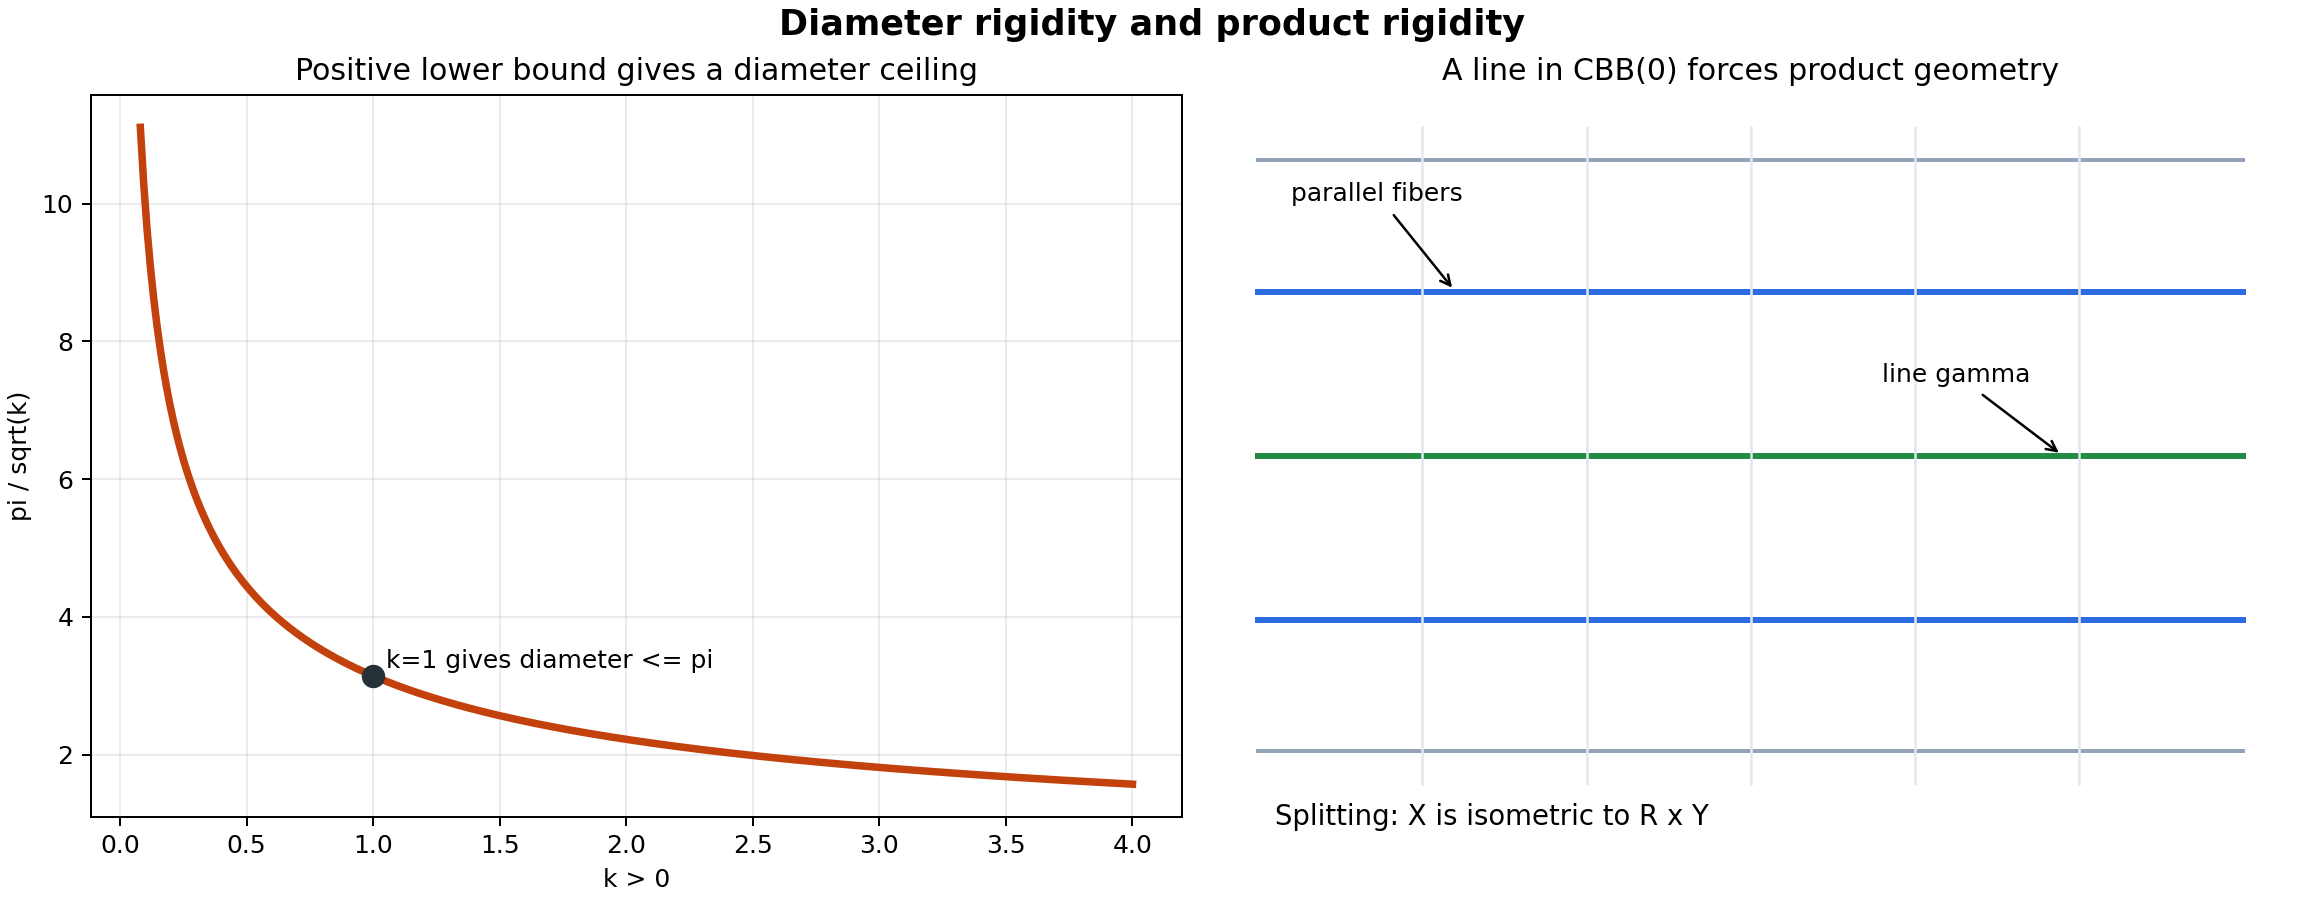

In [5]:
diam_path = FIG_DIR / "diameter-splitting-models.png"
diam_json = CHECK_DIR / "diameter-splitting-invariants.json"
ks = np.linspace(0.08, 4.0, 300)
diam_bounds = math.pi / np.sqrt(ks)
fig, axs = plt.subplots(1, 2, figsize=(12.8, 5.0), constrained_layout=True)
ax = axs[0]
ax.plot(ks, diam_bounds, color=STYLE["red"], lw=3)
ax.scatter([1], [math.pi], color=STYLE["ink"], s=70, zorder=5)
ax.text(1.05, math.pi + 0.12, "k=1 gives diameter <= pi", fontsize=10)
ax.set_title("Positive lower bound gives a diameter ceiling"); ax.set_xlabel("k > 0"); ax.set_ylabel("pi / sqrt(k)"); ax.grid(alpha=0.25)
ax = axs[1]
xx = np.linspace(-3.0, 3.0, 180)
for y, color in [(-1.0, STYLE["blue"]), (0.0, STYLE["green"]), (1.0, STYLE["blue"]), (1.8, "#94a3b8"), (-1.8, "#94a3b8")]:
    ax.plot(xx, np.full_like(xx, y), color=color, lw=2.4 if abs(y) <= 1 else 1.6)
for x0 in [-2, -1, 0, 1, 2]:
    ax.plot([x0, x0], [-2.0, 2.0], color="#e2e8f0", lw=1)
ax.annotate("line gamma", xy=(1.9, 0), xytext=(0.8, 0.45), arrowprops={"arrowstyle": "->"}, fontsize=10)
ax.annotate("parallel fibers", xy=(-1.8, 1.0), xytext=(-2.8, 1.55), arrowprops={"arrowstyle": "->"}, fontsize=10)
ax.text(-2.9, -2.25, "Splitting: X is isometric to R x Y", fontsize=11)
ax.set_title("A line in CBB(0) forces product geometry"); ax.set_aspect("equal"); ax.axis("off")
fig.suptitle("Diameter rigidity and product rigidity", fontsize=14, weight="bold")
fig.savefig(diam_path, dpi=180); plt.close(fig)
diam_json.write_text(json.dumps({"diameter_bound_k_1": math.pi, "diameter_bound_decreases_with_k": bool(np.all(np.diff(diam_bounds) < 0)), "splitting_hypotheses": ["locally compact", "curvature >= 0", "contains a complete geodesic line"], "splitting_conclusion": "metric product R x Y"}, indent=2), encoding="utf-8")
display_artifact(diam_path, width=980)


## Dimension, Volume, and Gromov-Hausdorff Limits

The chapter proves that finite-dimensional Alexandrov spaces have homogeneous integer dimension, then uses volume comparison to control families of spaces. The Gromov-Bishop and Bishop inequalities say that balls in an `n`-dimensional CBB(k) space grow no faster than balls in the constant-curvature `n`-model. This is exactly the kind of estimate needed for compactness.

Gromov-Hausdorff limits preserve the lower curvature bound, but dimension can collapse. Thinner and thinner flat rectangles illustrate how a nonnegatively curved family can converge to an interval-like space.


C:\Users\rahul\AppData\Local\Temp\ipykernel_37796\2573228998.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(omega * np.trapz(sn_k(ts, k) ** (n - 1), ts))


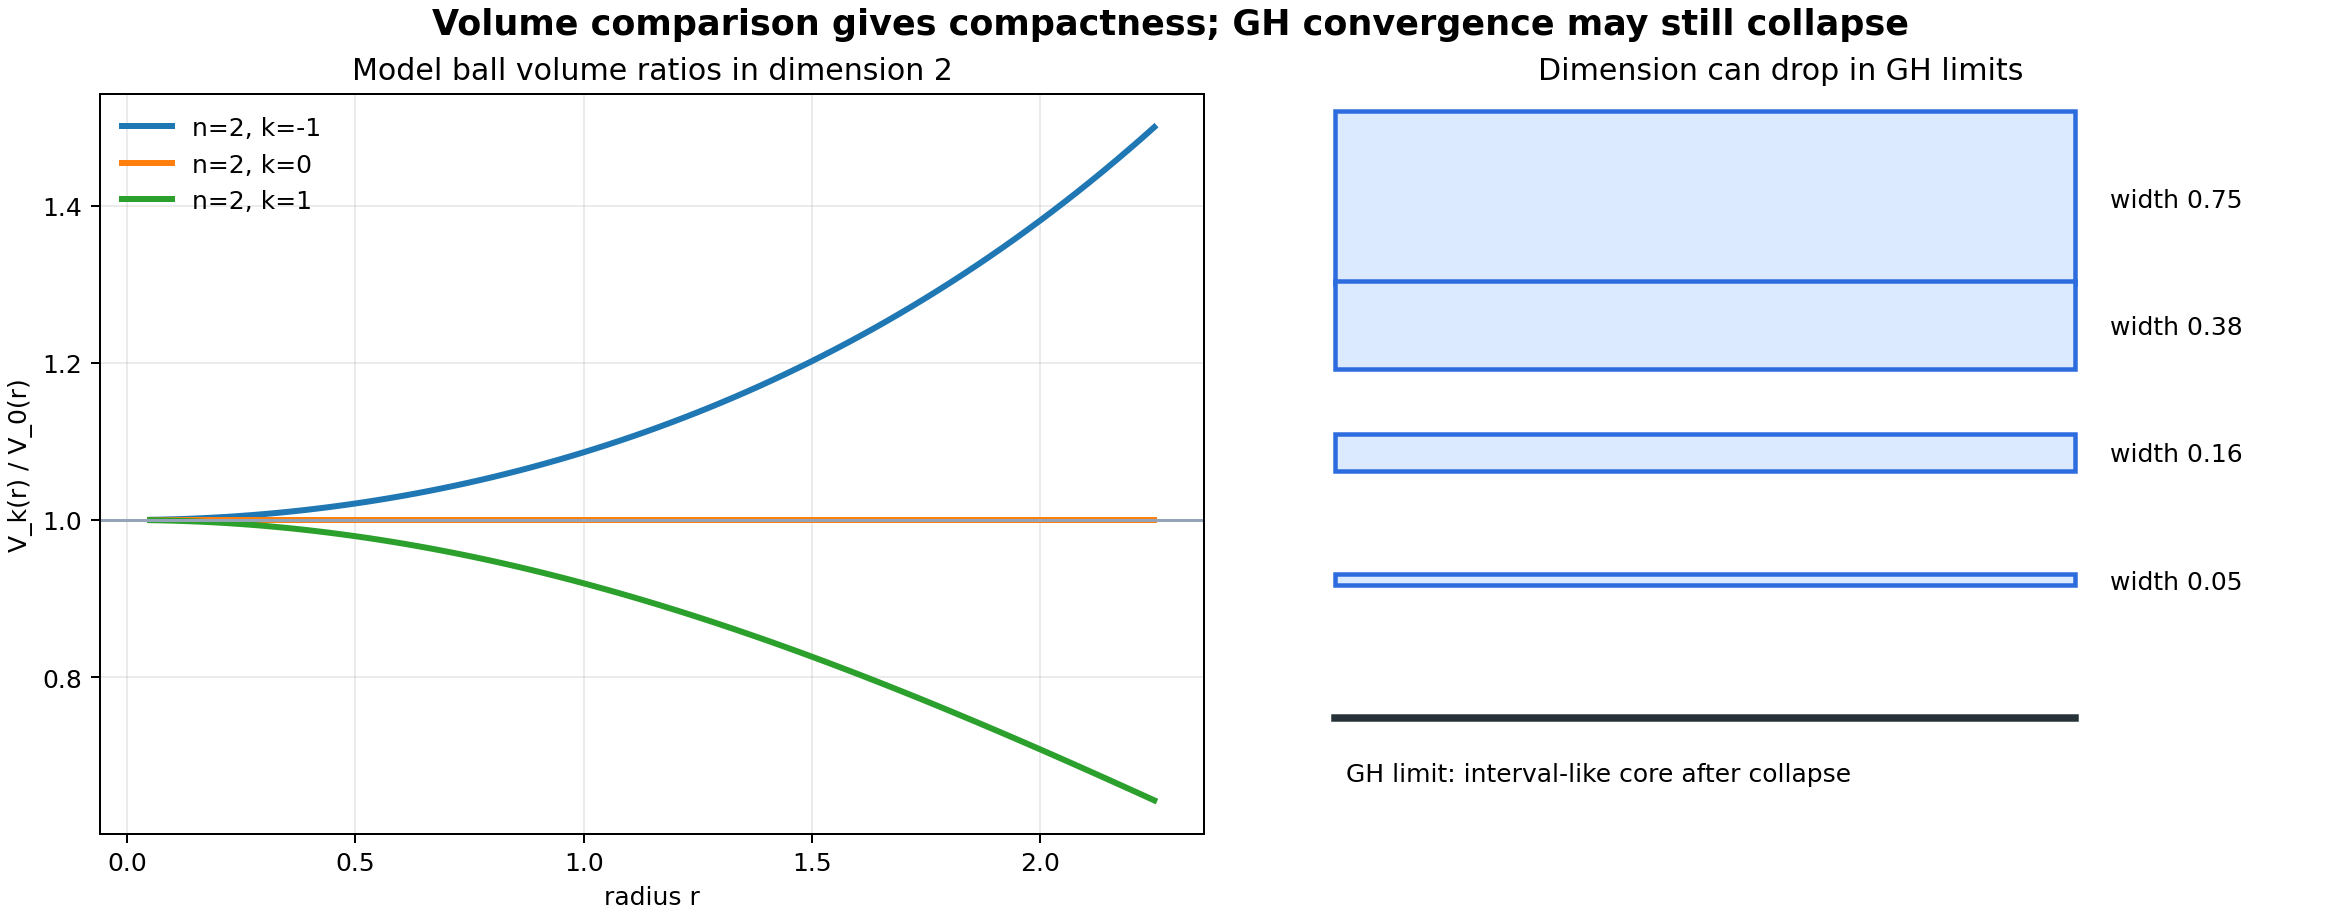

,dimension,k,r,model_volume,euclidean_volume_same_dim,ratio_to_euclidean
0,2,-1.0,0.050000,0.007856,0.007854,1.000208
1,2,-1.0,0.077848,0.019049,0.019039,1.000505
2,2,-1.0,0.105696,0.035130,0.035097,1.000931
3,2,-1.0,0.133544,0.056111,0.056027,1.001487
4,2,-1.0,0.161392,0.082008,0.081831,1.002173
5,2,-1.0,0.189241,0.112843,0.112507,1.002988


In [6]:
volume_path = FIG_DIR / "volume-gh-limit-collapse.png"
volume_csv = TABLE_DIR / "bishop-volume-ratios.csv"
volume_json = CHECK_DIR / "volume-gh-invariants.json"
radii = np.linspace(0.05, 2.25, 80)
records = []
for n in [2, 3]:
    for k in [-1.0, 0.0, 1.0]:
        for r in radii:
            records.append({"dimension": n, "k": k, "r": float(r), "model_volume": ball_volume_model(n, k, float(r))})
vol_df = pd.DataFrame(records)
vol_df["euclidean_volume_same_dim"] = [ball_volume_model(int(row.dimension), 0.0, float(row.r)) for row in vol_df.itertuples()]
vol_df["ratio_to_euclidean"] = vol_df["model_volume"] / vol_df["euclidean_volume_same_dim"]
vol_df.to_csv(volume_csv, index=False)

fig, axs = plt.subplots(1, 2, figsize=(13.0, 5.1), constrained_layout=True)
ax = axs[0]
for (n, k), grp in vol_df.groupby(["dimension", "k"]):
    if n == 2:
        ax.plot(grp["r"], grp["ratio_to_euclidean"], lw=2.4, label=f"n={n}, k={k:g}")
ax.axhline(1, color="#94a3b8", lw=1.2)
ax.set_title("Model ball volume ratios in dimension 2"); ax.set_xlabel("radius r"); ax.set_ylabel("V_k(r) / V_0(r)"); ax.grid(alpha=0.25); ax.legend(frameon=False)
ax = axs[1]
widths = [0.75, 0.38, 0.16, 0.05]
for i, w in enumerate(widths):
    y0 = 1.2 - i * 0.55
    ax.add_patch(plt.Rectangle((-1.6, y0 - w / 2), 3.2, w, facecolor="#dbeafe", edgecolor=STYLE["blue"], lw=1.8))
    ax.text(1.75, y0 - 0.04, f"width {w:.2f}", fontsize=10)
ax.plot([-1.6, 1.6], [-1.05, -1.05], color=STYLE["ink"], lw=3)
ax.text(-1.55, -1.32, "GH limit: interval-like core after collapse", fontsize=10)
ax.set_title("Dimension can drop in GH limits"); ax.set_xlim(-1.9, 2.55); ax.set_ylim(-1.55, 1.65); ax.set_aspect("equal"); ax.axis("off")
fig.suptitle("Volume comparison gives compactness; GH convergence may still collapse", fontsize=14, weight="bold")
fig.savefig(volume_path, dpi=180); plt.close(fig)
ratio_k1 = vol_df[(vol_df.dimension == 2) & (vol_df.k == 1.0)].sort_values("r")["ratio_to_euclidean"].to_numpy()
ratio_kminus1 = vol_df[(vol_df.dimension == 2) & (vol_df.k == -1.0)].sort_values("r")["ratio_to_euclidean"].to_numpy()
volume_json.write_text(json.dumps({"positive_model_ratio_decreases_initially": bool(ratio_k1[-1] < ratio_k1[0]), "negative_model_ratio_increases": bool(ratio_kminus1[-1] > ratio_kminus1[0]), "collapse_widths_decrease": bool(all(a > b for a, b in zip(widths, widths[1:]))), "csv_rows": int(len(vol_df))}, indent=2), encoding="utf-8")
display_artifact(volume_path, width=980)
vol_df.head(6)


## Local Properties: Strainers, Directions, and Tangent Cones

Sections 10.8 and 10.9 explain why finite-dimensional Alexandrov spaces have a large manifold-like part. A **strainer** is a collection of point pairs that behave like opposite coordinate directions. Enough good strainer pairs give distance coordinates, local compactness, integer dimension, and an open dense manifold set.

At each point `p`, directions of geodesics form `Sigma_p X`; the tangent cone is the cone over that space of directions. A point is regular exactly when `Sigma_p X` is the standard sphere, equivalently when the tangent cone is Euclidean.


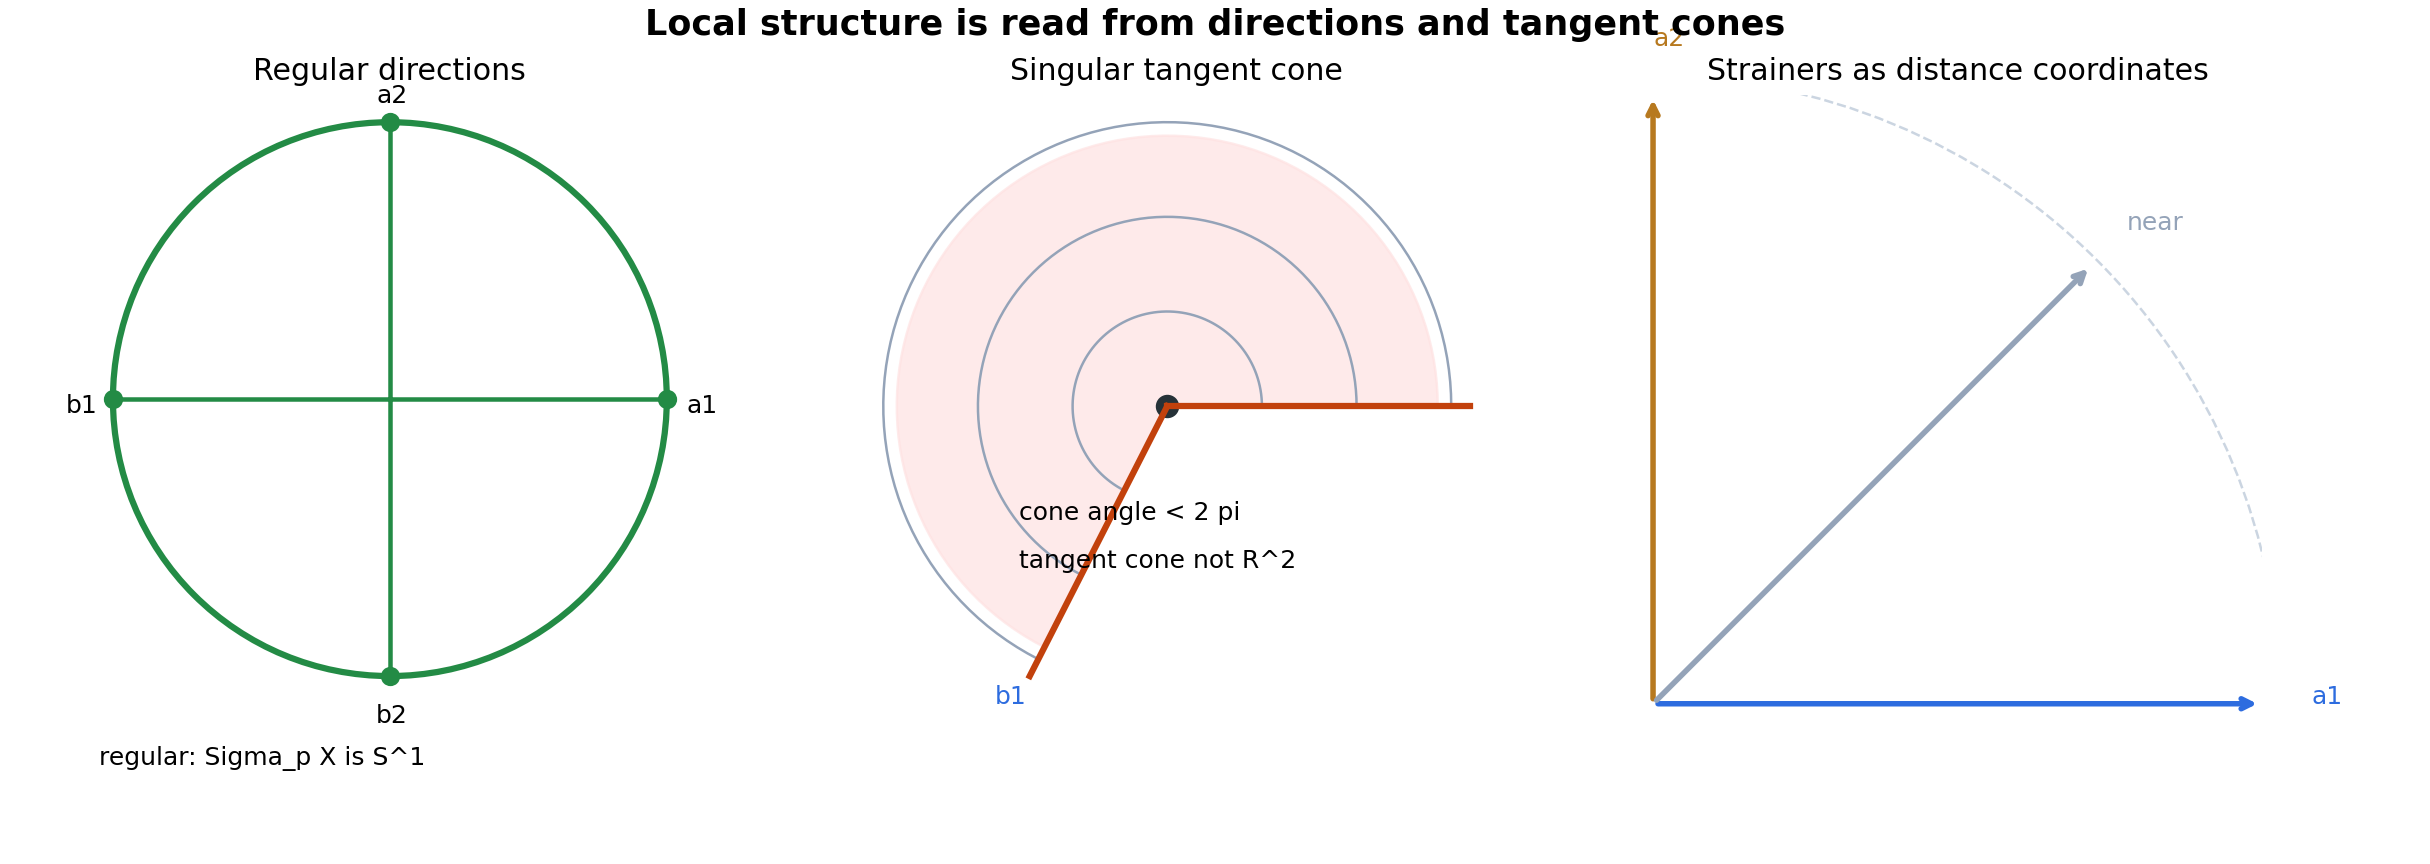

In [7]:
tangent_path = FIG_DIR / "directions-tangent-cone-strainers.png"
tangent_json = CHECK_DIR / "directions-tangent-cone-invariants.json"
fig, axs = plt.subplots(1, 3, figsize=(13.5, 4.8), constrained_layout=True)
ax = axs[0]
ax.add_patch(plt.Circle((0, 0), 1, fill=False, color=STYLE["green"], lw=2.5))
for t, label in zip([0, math.pi/2, math.pi, 3*math.pi/2], ["a1", "a2", "b1", "b2"]):
    ax.plot([0, math.cos(t)], [0, math.sin(t)], color=STYLE["green"], lw=1.8)
    ax.scatter([math.cos(t)], [math.sin(t)], color=STYLE["green"], s=45)
    ax.text(1.12*math.cos(t)-0.05, 1.12*math.sin(t)-0.05, label, fontsize=10)
ax.text(-1.05, -1.32, "regular: Sigma_p X is S^1", fontsize=10); ax.set_title("Regular directions"); ax.set_aspect("equal"); ax.axis("off")
ax = axs[1]
alpha2 = 1.35 * math.pi; ts2 = np.linspace(0, alpha2, 100)
for rr in [0.35, 0.7, 1.05]:
    ax.plot(rr*np.cos(ts2), rr*np.sin(ts2), color="#94a3b8", lw=1)
for t in [0, alpha2]:
    ax.plot([0, 1.12*math.cos(t)], [0, 1.12*math.sin(t)], color=STYLE["red"], lw=2.5)
ax.fill(np.r_[0, np.cos(ts2), 0], np.r_[0, np.sin(ts2), 0], color="#fee2e2", alpha=0.70)
ax.scatter([0], [0], s=70, color=STYLE["ink"])
ax.text(-0.55, -0.42, "cone angle < 2 pi", fontsize=10); ax.text(-0.55, -0.60, "tangent cone not R^2", fontsize=10)
ax.set_title("Singular tangent cone"); ax.set_aspect("equal"); ax.axis("off")
ax = axs[2]
for (dx, dy), color, label in zip([(1,0), (-1,0), (0,1), (0,-1), (0.72,0.72), (-0.72,-0.72)], [STYLE["blue"], STYLE["blue"], STYLE["gold"], STYLE["gold"], "#94a3b8", "#94a3b8"], ["a1", "b1", "a2", "b2", "near", "near"]):
    ax.annotate("", xy=(dx, dy), xytext=(0, 0), arrowprops={"arrowstyle": "->", "lw": 2.2, "color": color})
    ax.text(1.08*dx, 1.08*dy, label, fontsize=10, color=color)
ax.add_patch(plt.Circle((0,0), 1.03, fill=False, ls="--", color="#cbd5e1"))
ax.text(-1.2, -1.32, "strainer pairs approximate coordinate axes", fontsize=10)
ax.set_title("Strainers as distance coordinates"); ax.set_aspect("equal"); ax.axis("off")
fig.suptitle("Local structure is read from directions and tangent cones", fontsize=14, weight="bold")
fig.savefig(tangent_path, dpi=180); plt.close(fig)
tangent_json.write_text(json.dumps({"regular_link_length_over_pi_in_2d": 2.0, "singular_cone_angle_over_pi": alpha2 / math.pi, "regular_tangent_cone": "Euclidean R^n exactly when the space of directions is S^(n-1)", "strainer_pairs_drawn": 2}, indent=2), encoding="utf-8")
display_artifact(tangent_path, width=980)


## Applied Lab: Vary the Lower Bound in a Hinge

The standalone HTML artifact below keeps two legs and the included angle fixed, then recomputes the model opposite side as `k` varies from negative to positive. The model space is the measuring stick used by the comparison theorem; the lab makes that measuring stick visible.


In [8]:
html_path = HTML_DIR / "toponogov-hinge-lab.html"
html = r'''<!doctype html><html lang="en"><head><meta charset="utf-8"/><title>Toponogov hinge lab</title>
<style>body{font-family:system-ui,Segoe UI,sans-serif;margin:24px;color:#1f2937;background:#f8fafc}main{max-width:920px;margin:auto;background:white;border:1px solid #cbd5e1;padding:20px}h1{font-size:22px;margin:0 0 8px}label{display:block;margin-top:12px;font-weight:650}input{width:100%}svg{width:100%;height:360px;border:1px solid #e2e8f0;background:#fff;margin-top:16px}.metric{display:grid;grid-template-columns:repeat(3,1fr);gap:12px;margin-top:12px}.metric div{background:#f1f5f9;padding:10px;border-left:4px solid #2d6cdf}</style></head>
<body><main><h1>Toponogov hinge lab</h1><p>Two legs and the included angle stay fixed. The model opposite side changes with curvature parameter k.</p>
<label for="k">model curvature k: <span id="kv"></span></label><input id="k" type="range" min="-1" max="1" step="0.01" value="0"/>
<svg id="svg" viewBox="0 0 700 360" role="img" aria-label="hinge model"></svg><div class="metric"><div>leg a: <strong>1.25</strong></div><div>leg b: <strong>1.05</strong></div><div>opposite side: <strong id="side"></strong></div></div>
<p>The CBB reading: a lower curvature bound prevents hinges from spreading more than the corresponding model hinge.</p></main>
<script>const legA=1.25,legB=1.05,theta=64*Math.PI/180;function clamp(x,lo,hi){return Math.max(lo,Math.min(hi,x));}function side(k){if(Math.abs(k)<1e-10)return Math.sqrt(legA*legA+legB*legB-2*legA*legB*Math.cos(theta));const root=Math.sqrt(Math.abs(k));if(k>0){const v=Math.cos(root*legA)*Math.cos(root*legB)+Math.sin(root*legA)*Math.sin(root*legB)*Math.cos(theta);return Math.acos(clamp(v,-1,1))/root;}const v=Math.cosh(root*legA)*Math.cosh(root*legB)-Math.sinh(root*legA)*Math.sinh(root*legB)*Math.cos(theta);return Math.acosh(Math.max(1,v))/root;}function draw(){const k=parseFloat(document.getElementById('k').value),c=side(k);document.getElementById('kv').textContent=k.toFixed(2);document.getElementById('side').textContent=c.toFixed(4);const scale=115,ox=165,oy=240,p1=[ox+scale*legA,oy],p2=[ox+scale*legB*Math.cos(theta),oy-scale*legB*Math.sin(theta)],hue=k<-0.02?'#6d4c9f':(k>0.02?'#c2410c':'#238b45');document.getElementById('svg').innerHTML=`<line x1="${ox}" y1="${oy}" x2="${p1[0]}" y2="${p1[1]}" stroke="#334155" stroke-width="4"/><line x1="${ox}" y1="${oy}" x2="${p2[0]}" y2="${p2[1]}" stroke="#334155" stroke-width="4"/><line x1="${p1[0]}" y1="${p1[1]}" x2="${p2[0]}" y2="${p2[1]}" stroke="${hue}" stroke-width="5" stroke-dasharray="8 6"/><circle cx="${ox}" cy="${oy}" r="7" fill="#111827"/><circle cx="${p1[0]}" cy="${p1[1]}" r="7" fill="#2d6cdf"/><circle cx="${p2[0]}" cy="${p2[1]}" r="7" fill="#2d6cdf"/><text x="${ox-14}" y="${oy+25}" font-size="18">p</text><text x="${p1[0]+8}" y="${p1[1]+5}" font-size="18">x</text><text x="${p2[0]+8}" y="${p2[1]-8}" font-size="18">y</text><text x="410" y="115" font-size="18" fill="${hue}">model side c_k = ${c.toFixed(4)}</text><text x="410" y="145" font-size="15" fill="#475569">smaller c_k means less permitted spread</text>`;}document.getElementById('k').addEventListener('input',draw);draw();</script></body></html>'''
html_path.write_text(html, encoding="utf-8")
display_artifact(html_path)


## Further Information: What the Later Results Add

- **Stratification and stability.** Finite-dimensional Alexandrov spaces decompose into manifold strata, and small Gromov-Hausdorff perturbations preserve homeomorphism type under fixed dimension and lower curvature.
- **Boundary and extremal sets.** The boundary can be defined inductively through boundaries of spaces of directions; extremal sets behave well under gradient-like flows.
- **Soul and convexity methods.** Noncompact nonnegatively curved Alexandrov spaces have a compact totally convex soul, extending the Riemannian picture but allowing new singular phenomena.
- **Hausdorff measure and collapse.** Nonregular points have zero measure in the relevant dimension, but sequences can collapse to lower-dimensional limits.
- **Quasigeodesics and analysis.** Geodesics may be scarce through singular points, so quasigeodesics and gradient curves supply a better calculus. With curvature bounded on both sides, strong regularity theorems recover a Riemannian-like structure away from boundary issues.


## Visual Storyboard and Source Coverage Ledger

The ledger below maps every source section in Chapter 10 to notebook treatment. It is intentionally a coverage artifact, not a source-text extraction.


In [9]:
coverage_path = CHECK_DIR / "chapter-10-source-coverage.json"
storyboard_path = CHECK_DIR / "visual-storyboard.json"
sections = [
    {"section": "10.1", "title": "One More Definition", "printed_start": 352, "pdf_start": 367, "notebook_treatment": "quadruple fan and CBB(k) translation"},
    {"section": "10.2", "title": "Constructions and Examples", "printed_start": 354, "pdf_start": 369, "notebook_treatment": "cones, quotients, convex surfaces"},
    {"section": "10.3", "title": "Toponogov's Theorem", "printed_start": 360, "pdf_start": 375, "notebook_treatment": "hinge comparison, interactive lab, proof dependency graph"},
    {"section": "10.4", "title": "Curvature and Diameter", "printed_start": 364, "pdf_start": 379, "notebook_treatment": "positive-curvature diameter bound"},
    {"section": "10.5", "title": "Splitting Theorem", "printed_start": 366, "pdf_start": 381, "notebook_treatment": "line-to-product rigidity diagram"},
    {"section": "10.6", "title": "Dimension and Volume", "printed_start": 369, "pdf_start": 384, "notebook_treatment": "dimension homogeneity notes and Bishop model-volume table"},
    {"section": "10.7", "title": "Gromov-Hausdorff Limits", "printed_start": 376, "pdf_start": 391, "notebook_treatment": "closure, compactness dependency, dimension-collapse diagram"},
    {"section": "10.8", "title": "Local Properties", "printed_start": 378, "pdf_start": 393, "notebook_treatment": "strainers, local compactness, regular dense set"},
    {"section": "10.9", "title": "Spaces of Directions and Tangent Cones", "printed_start": 390, "pdf_start": 405, "notebook_treatment": "direction link and tangent cone visual"},
    {"section": "10.10", "title": "Further Information", "printed_start": 398, "pdf_start": 413, "notebook_treatment": "stratification, boundary, soul, collapse, quasigeodesics, analysis, two-sided bounds"},
]
coverage = {"book": "A Course in Metric Geometry", "chapter": 10, "source_span": {"printed_pages": "351-404", "pdf_pages": "366-419"}, "source_use": "orientation, theorem order, terminology, and coverage only; no copied prose or page crops", "sections": sections, "artifacts_by_concept": {"quadruple_and_toponogov": rel(quad_path), "constructions_examples": rel(construction_path), "proof_dependency": rel(proof_path), "diameter_splitting": rel(diam_path), "volume_and_gh_limits": rel(volume_path), "directions_tangent_cones": rel(tangent_path), "interactive_hinge_lab": rel(html_path)}}
coverage_path.write_text(json.dumps(coverage, indent=2), encoding="utf-8")
storyboard = [
    {"concept": "CBB definition and Toponogov hinge", "artifact": rel(quad_path), "check": rel(hinge_json), "inspection_target": "comparison angle fan and model-side monotonicity"},
    {"concept": "constructions and examples", "artifact": rel(construction_path), "check": rel(construction_json), "inspection_target": "links, quotient folds, and convex intrinsic metrics"},
    {"concept": "proof architecture", "artifact": rel(proof_path), "check": rel(proof_json), "inspection_target": "Toponogov as a dependency hub"},
    {"concept": "diameter and splitting", "artifact": rel(diam_path), "check": rel(diam_json), "inspection_target": "positive diameter ceiling and line-to-product rigidity"},
    {"concept": "dimension, volume, and GH limits", "artifact": rel(volume_path), "check": rel(volume_json), "inspection_target": "Bishop model ratios and collapse"},
    {"concept": "directions and tangent cones", "artifact": rel(tangent_path), "check": rel(tangent_json), "inspection_target": "regular link vs singular cone and strainer pairs"},
]
storyboard_path.write_text(json.dumps(storyboard, indent=2), encoding="utf-8")
pd.DataFrame(sections)


,section,title,printed_start,pdf_start,notebook_treatment
0,10.1,One More Definition,352,367,quadruple fan and CBB(k) translation
1,10.2,Constructions and Examples,354,369,"cones, quotients, convex surfaces"
2,10.3,Toponogov's Theorem,360,375,"hinge comparison, interactive lab, proof depen..."
3,10.4,Curvature and Diameter,364,379,positive-curvature diameter bound
4,10.5,Splitting Theorem,366,381,line-to-product rigidity diagram
5,10.6,Dimension and Volume,369,384,dimension homogeneity notes and Bishop model-v...
6,10.7,Gromov-Hausdorff Limits,376,391,"closure, compactness dependency, dimension-col..."
7,10.8,Local Properties,378,393,"strainers, local compactness, regular dense set"
8,10.9,Spaces of Directions and Tangent Cones,390,405,direction link and tangent cone visual
9,10.10,Further Information,398,413,"stratification, boundary, soul, collapse, quas..."


## Final Sanity Checks

These checks are deliberately concrete: every named artifact must exist, every PNG must be nonblank, numerical comparison invariants must hold, and every source section must have a notebook treatment.


In [10]:
final_sanity_path = CHECK_DIR / "final-sanity.json"
all_artifacts = [quad_path, construction_path, proof_path, diam_path, volume_path, tangent_path, html_path, volume_csv, coverage_path, storyboard_path, hinge_json, construction_json, proof_json, diam_json, volume_json, tangent_json]
artifact_records = []
for path in all_artifacts:
    record = {"path": rel(path), "exists": path.exists(), "bytes": path.stat().st_size if path.exists() else 0}
    if path.suffix.lower() == ".png" and path.exists():
        img = mpimg.imread(path)
        record["pixel_std"] = float(np.std(img))
        record["nonblank"] = bool(np.std(img) > 0.002)
    artifact_records.append(record)
loaded_hinge = json.loads(hinge_json.read_text(encoding="utf-8"))
loaded_proof = json.loads(proof_json.read_text(encoding="utf-8"))
loaded_coverage = json.loads(coverage_path.read_text(encoding="utf-8"))
loaded_volume = json.loads(volume_json.read_text(encoding="utf-8"))
final_sanity = {
    "source_sections_covered": len(loaded_coverage["sections"]),
    "expected_source_sections": 10,
    "artifact_records": artifact_records,
    "numeric_checks": {
        "toponogov_side_monotone": loaded_hinge["side_decreases_as_k_increases"],
        "quadruple_fan_calibrates_2pi": loaded_hinge["quadruple_fan_sum_minus_2pi_abs"] < 1e-10,
        "proof_graph_is_dag": loaded_proof["is_directed_acyclic_graph"],
        "volume_collapse_widths_decrease": loaded_volume["collapse_widths_decrease"],
    },
}
final_sanity_path.write_text(json.dumps(final_sanity, indent=2), encoding="utf-8")
assert final_sanity["source_sections_covered"] == final_sanity["expected_source_sections"]
assert all(item["exists"] and item["bytes"] > (200 if item["path"].endswith((".png", ".html", ".csv")) else 20) for item in artifact_records)
assert all(item.get("nonblank", True) for item in artifact_records)
assert all(final_sanity["numeric_checks"].values())
final_sanity


{'source_sections_covered': 10,
 'expected_source_sections': 10,
 'artifact_records': [{'path': 'artifacts/chapter-10/figures/quadruple-toponogov-comparison.png',
   'exists': True,
   'bytes': 154916,
   'pixel_std': 0.13270451128482819,
   'nonblank': True},
  {'path': 'artifacts/chapter-10/figures/constructions-cones-quotients.png',
   'exists': True,
   'bytes': 154954,
   'pixel_std': 0.11600219458341599,
   'nonblank': True},
  {'path': 'artifacts/chapter-10/figures/chapter-10-proof-dependency.png',
   'exists': True,
   'bytes': 220177,
   'pixel_std': 0.09986194968223572,
   'nonblank': True},
  {'path': 'artifacts/chapter-10/figures/diameter-splitting-models.png',
   'exists': True,
   'bytes': 87066,
   'pixel_std': 0.12389364093542099,
   'nonblank': True},
  {'path': 'artifacts/chapter-10/figures/volume-gh-limit-collapse.png',
   'exists': True,
   'bytes': 102349,
   'pixel_std': 0.13799399137496948,
   'nonblank': True},
  {'path': 'artifacts/chapter-10/figures/directions

## Takeaways

- A CBB lower bound is most inspectable through comparison angles and hinges: it restricts how geodesics spread relative to the model plane.
- Toponogov is the hinge that swings the whole chapter: local lower curvature becomes global triangle comparison, and that feeds diameter, splitting, compactness, and tangent-cone structure.
- Singular spaces are not exceptions to the theory. Cones, quotients, convex surfaces, and collapsed limits show why spaces of directions are the right local objects.
- Finite-dimensional Alexandrov spaces are mostly manifold-like: strainers produce local coordinates, regular points are dense, and tangent cones explain both regularity and singularity.
- The further theory is powerful but technically heavy: stratification, stability, souls, quasigeodesics, and analysis on Alexandrov spaces extend the chapter's comparison tools into a full geometric calculus.
